<a href="https://www.kaggle.com/code/pawanthapaliya/heart-attack-dataset?scriptVersionId=237425475" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-attack-dataset-tarik-a-rashid/Medicaldataset.csv


Import Libraries

Load Dataset

Initial Data Exploration

Data Cleaning

    Checking and handling missing values

    Checking for duplicates

Data Visualization and feature engineering

    Distribution of target variable

    Boxplots for outlier detection

Data Summary and Modeling results

In [2]:
# Import Required Libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

In [3]:

# Dataset
print("Loading dataset...")
df = pd.read_csv('/kaggle/input/heart-attack-dataset-tarik-a-rashid/Medicaldataset.csv')
print("Dataset loaded successfully!")


Loading dataset...
Dataset loaded successfully!


In [4]:
# Initial Data Exploration
print("\n--- Dataset Overview ---")
print("Shape:", df.shape)
print("Data Types:\n", df.dtypes)
print("First 5 Rows:\n", df.head())
df.info()
print("\nStatistical Summary (Numerical):\n", df.describe())
print("\nStatistical Summary (Categorical):\n", df.describe(include='object'))
print("\nColumn Names:", df.columns)


--- Dataset Overview ---
Shape: (1319, 9)
Data Types:
 Age                           int64
Gender                        int64
Heart rate                    int64
Systolic blood pressure       int64
Diastolic blood pressure      int64
Blood sugar                 float64
CK-MB                       float64
Troponin                    float64
Result                       object
dtype: object
First 5 Rows:
    Age  Gender  Heart rate  Systolic blood pressure  Diastolic blood pressure  \
0   64       1          66                      160                        83   
1   21       1          94                       98                        46   
2   55       1          64                      160                        77   
3   64       1          70                      120                        55   
4   55       1          64                      112                        65   

   Blood sugar  CK-MB  Troponin    Result  
0        160.0   1.80     0.012  negative  
1        296.0  


--- Missing Values ---
Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
dtype: int64


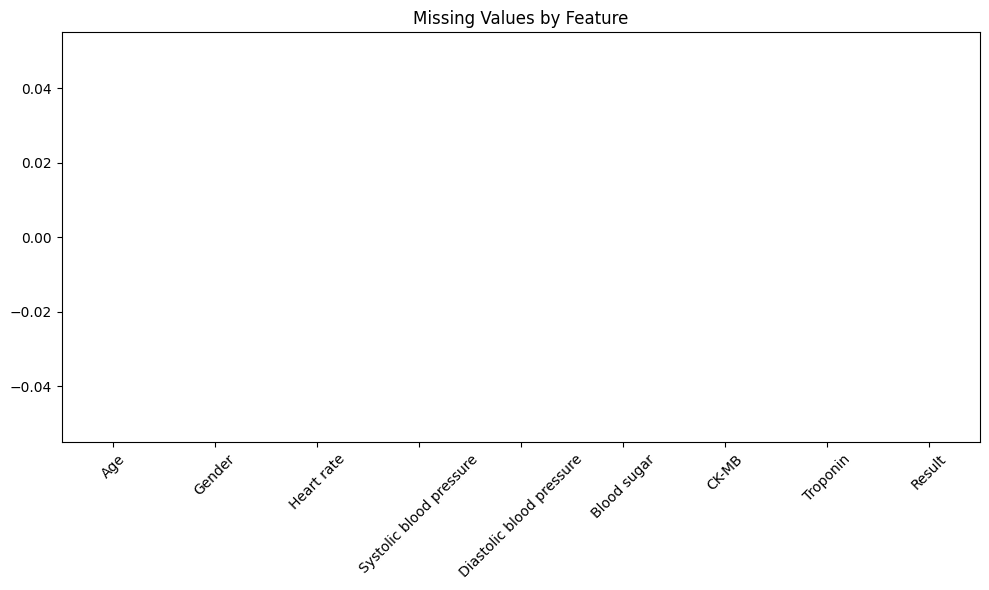

Number of duplicated rows: 0


In [5]:
# Data Cleaning and Preprocessing

# Check Missing Values
print("\n--- Missing Values ---")
missing_values = df.isnull().sum()
print(missing_values)

# Visualize missing values
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.xticks(rotation=45)
plt.title('Missing Values by Feature')
plt.tight_layout()
plt.show()

# Check for Duplicates
duplicates = df.duplicated().sum()
print("Number of duplicated rows:", duplicates)

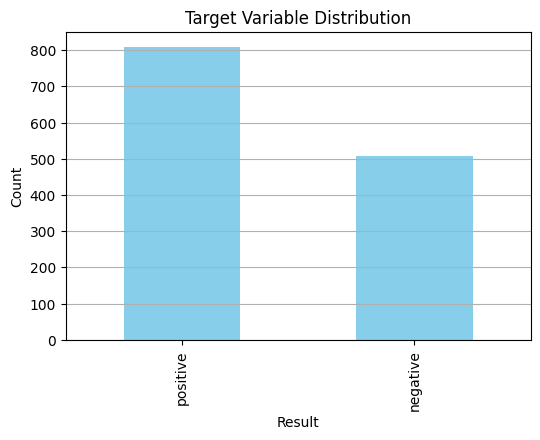

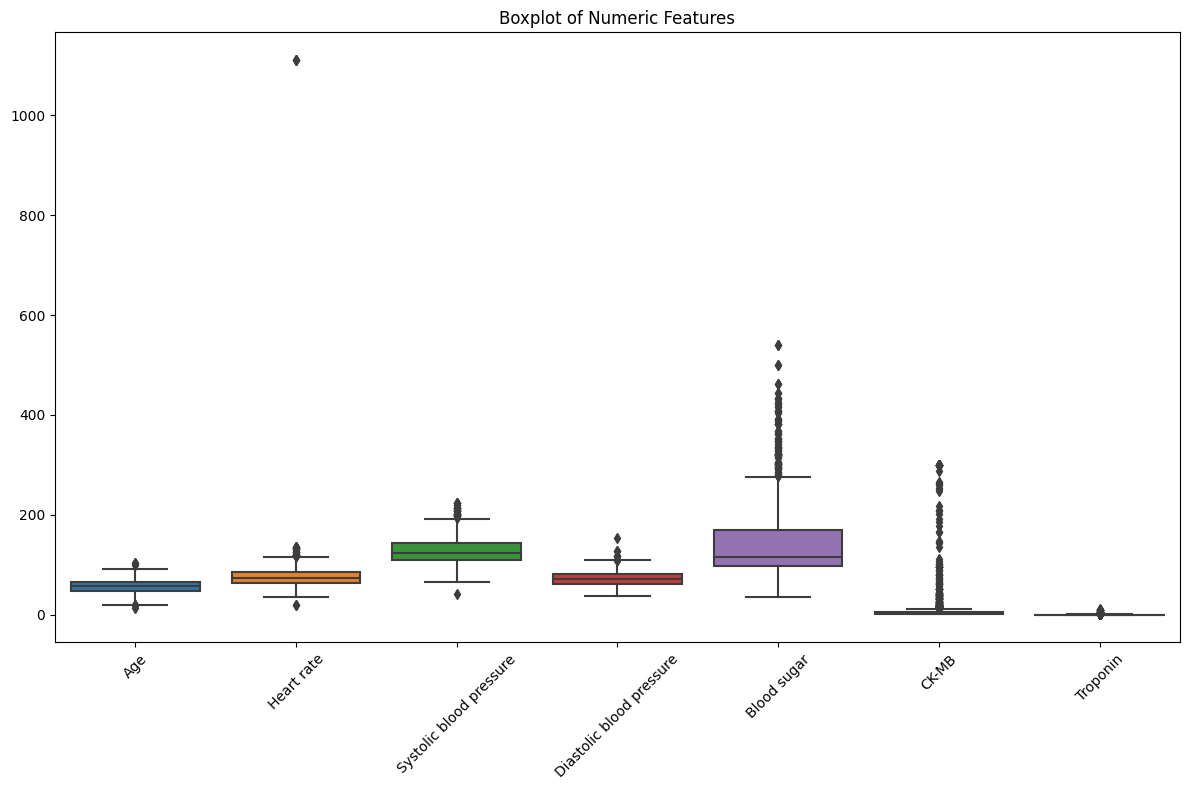

In [6]:
# Exploratory Data Analysis (EDA)

# Target Variable Distribution
plt.figure(figsize=(6, 4))
df['Result'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Target Variable Distribution')
plt.xlabel('Result')
plt.ylabel('Count')
plt.grid(axis='y')
plt.show()

#  Boxplots for Outlier Detection
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[['Age', 'Heart rate', 'Systolic blood pressure', 
                     'Diastolic blood pressure', 'Blood sugar', 
                     'CK-MB', 'Troponin']])
plt.xticks(rotation=45)
plt.title('Boxplot of Numeric Features')
plt.tight_layout()
plt.show()


In [7]:
# Feature Engineering 
print('Creating new features')
df['BP Difference'] = df['Systolic blood pressure'] - df['Diastolic blood pressure']
df['Pulse Pressure'] = df['Systolic blood pressure'] - df['Diastolic blood pressure']
df['Mean Arterial Pressure'] = (df['Systolic blood pressure'] + 2 * df['Diastolic blood pressure']) / 3
df['Shock Index'] = df['Heart rate'] / df['Systolic blood pressure']

# Check
print("\n--- New Features Added ---")
print(df[['BP Difference', 'Pulse Pressure', 'Mean Arterial Pressure', 'Shock Index']].head())



Creating new features

--- New Features Added ---
   BP Difference  Pulse Pressure  Mean Arterial Pressure  Shock Index
0             77              77              108.666667     0.412500
1             52              52               63.333333     0.959184
2             83              83              104.666667     0.400000
3             65              65               76.666667     0.583333
4             47              47               80.666667     0.571429


In [8]:
# Models

# Prepare features and target
X = df.drop(['Result'], axis=1)
y = df['Result']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)

# 5. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 6. Evaluation
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

=== Logistic Regression ===
Accuracy: 0.7992424242424242
              precision    recall  f1-score   support

    negative       0.76      0.70      0.73       101
    positive       0.82      0.86      0.84       163

    accuracy                           0.80       264
   macro avg       0.79      0.78      0.78       264
weighted avg       0.80      0.80      0.80       264

[[ 71  30]
 [ 23 140]]

=== Random Forest ===
Accuracy: 0.9810606060606061
              precision    recall  f1-score   support

    negative       0.97      0.98      0.98       101
    positive       0.99      0.98      0.98       163

    accuracy                           0.98       264
   macro avg       0.98      0.98      0.98       264
weighted avg       0.98      0.98      0.98       264

[[ 99   2]
 [  3 160]]


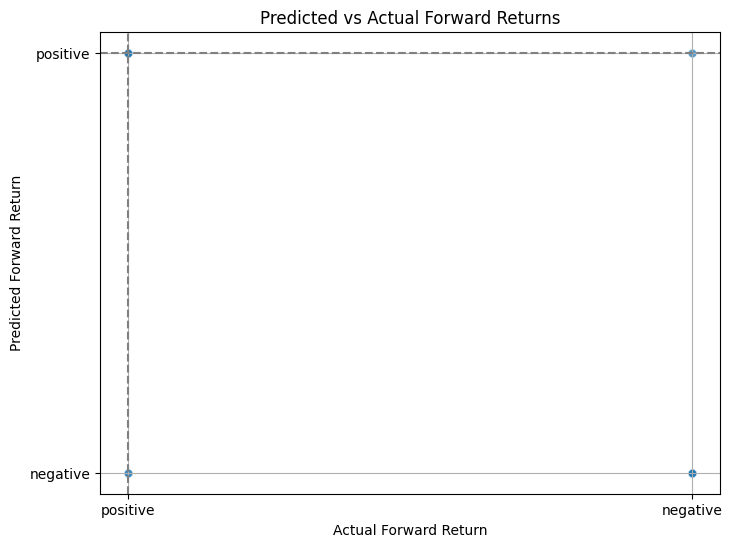

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5)
plt.xlabel("Actual Forward Return")
plt.ylabel("Predicted Forward Return")
plt.title("Predicted vs Actual Forward Returns")
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.grid(True)
plt.show()